# Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Dataset

In [2]:
train_data = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

In [3]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
train_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
(train_data.columns.drop('SalePrice') == test_data.columns).any()

True

In [7]:
# drop 'Id' columns from data train dataframe
train_data.drop(["Id"], axis=1, inplace=True)
# drop 'Id' column from test dataframe and save it in (id_test_list) to use it in submission.
id_test_list = test_data["Id"].tolist()
test_data.drop(["Id"], axis=1, inplace=True)

In [8]:
num_cols = []
cat_cols = []

for col in train_data.columns:
    if train_data[col].dtype in('int64','float64'):
        num_cols.append(train_data[col].name)
    else:
        cat_cols.append(train_data[col].name)

In [9]:
num_trainData = train_data[num_cols]
cat_trainData = train_data[cat_cols]

num_testData = test_data[num_cols[0:-1]]
cat_testData = test_data[cat_cols]

In [10]:
num_trainData.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [11]:
cat_trainData.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [12]:
from sklearn.feature_selection import VarianceThreshold
thresholder = VarianceThreshold(threshold=0.15)   # column where 85% of the values are constant
data_high_variance = thresholder.fit(num_trainData)

In [13]:
high_variance_list = []
for col in num_trainData.columns:
    if col not in num_trainData.columns[thresholder.get_support()]:
        high_variance_list.append(col)

high_variance_list

['BsmtHalfBath', 'KitchenAbvGr']

In [14]:
train_data.drop(high_variance_list, axis=1, inplace=True)
test_data.drop(high_variance_list, axis=1, inplace=True)

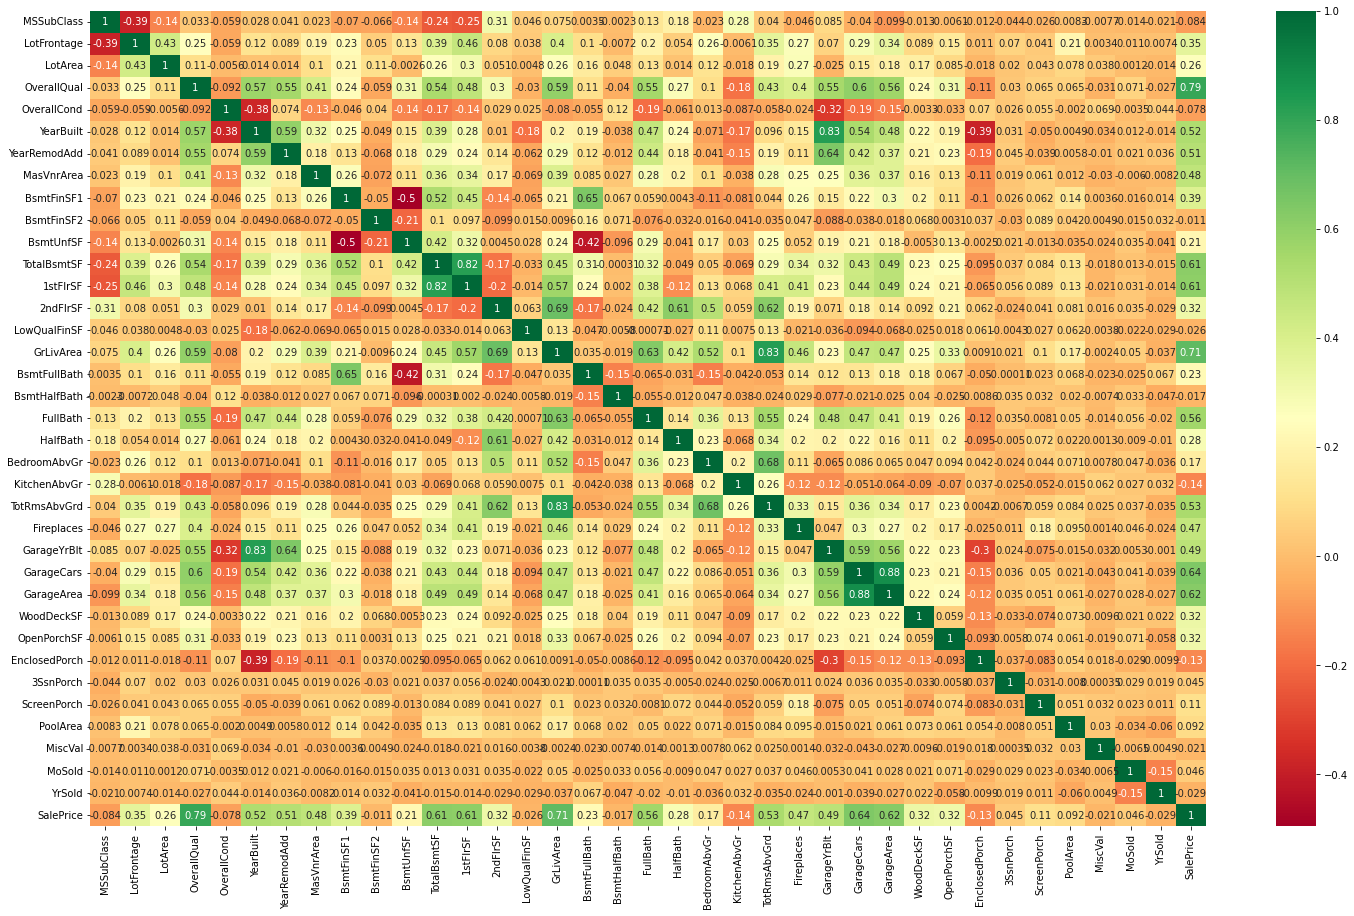

In [15]:

# Get correlation of all the features of the dataset
corr_matrix = num_trainData.corr()
top_corr_features = corr_matrix.index

# Plotting the heatmap
plt.figure(figsize=(25,15))
g = sns.heatmap(data=num_trainData[top_corr_features].corr(), annot=True, cmap='RdYlGn')

In [16]:
con1  = num_trainData.corr()['SalePrice'] < 0.25
con2 = num_trainData.corr()['SalePrice'] > -0.25
lowCorr = (num_trainData.corr()[con1 & con2]['SalePrice'].index).to_list()
lowCorr

['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [17]:
for i in range(len(lowCorr)):
    if i in train_data.columns:
        train_data.drop(lowCorr, axis=1, inplace=True)
        test_data.drop(lowCorr, axis=1, inplace=True)

In [18]:
train_data.drop_duplicates(inplace=True)
test_data.drop_duplicates(inplace=True)

In [19]:
print('number of duplicate values in df_train dataframe: ',train_data.duplicated().sum())
print('number of duplicate values in df_test dataframe: ',test_data.duplicated().sum())

number of duplicate values in df_train dataframe:  0
number of duplicate values in df_test dataframe:  0


In [20]:
def drop_missing(df):
    i = 0
    for col in df:
        if (df[col].isnull().sum()/1460) > 0.3:
            df.drop(col, axis=1, inplace=True)
            print('column',col,'is dropped')
            i += 1
    if i == 0:
        print('no column dropped')

In [21]:
drop_missing(train_data)

column Alley is dropped
column FireplaceQu is dropped
column PoolQC is dropped
column Fence is dropped
column MiscFeature is dropped


In [22]:
drop_missing(test_data)

column Alley is dropped
column FireplaceQu is dropped
column PoolQC is dropped
column Fence is dropped
column MiscFeature is dropped


In [23]:
def fill_null(df):
    for col in df:
        if (col in num_cols) & (df[col].isnull().any()):
            df[col].fillna(df[col].mean(), inplace = True)
            print('fillna numerical column: ',col)
        if (col in cat_cols) & (df[col].isnull().any()):
            df[col].fillna(df[col].mode().iloc[0], inplace = True)
            print('fillna categorical column: ',col)

In [24]:
fill_null(train_data)

fillna numerical column:  LotFrontage
fillna categorical column:  MasVnrType
fillna numerical column:  MasVnrArea
fillna categorical column:  BsmtQual
fillna categorical column:  BsmtCond
fillna categorical column:  BsmtExposure
fillna categorical column:  BsmtFinType1
fillna categorical column:  BsmtFinType2
fillna categorical column:  Electrical
fillna categorical column:  GarageType
fillna numerical column:  GarageYrBlt
fillna categorical column:  GarageFinish
fillna categorical column:  GarageQual
fillna categorical column:  GarageCond


In [25]:
fill_null(test_data)

fillna categorical column:  MSZoning
fillna numerical column:  LotFrontage
fillna categorical column:  Utilities
fillna categorical column:  Exterior1st
fillna categorical column:  Exterior2nd
fillna categorical column:  MasVnrType
fillna numerical column:  MasVnrArea
fillna categorical column:  BsmtQual
fillna categorical column:  BsmtCond
fillna categorical column:  BsmtExposure
fillna categorical column:  BsmtFinType1
fillna numerical column:  BsmtFinSF1
fillna categorical column:  BsmtFinType2
fillna numerical column:  BsmtFinSF2
fillna numerical column:  BsmtUnfSF
fillna numerical column:  TotalBsmtSF
fillna numerical column:  BsmtFullBath
fillna categorical column:  KitchenQual
fillna categorical column:  Functional
fillna categorical column:  GarageType
fillna numerical column:  GarageYrBlt
fillna categorical column:  GarageFinish
fillna numerical column:  GarageCars
fillna numerical column:  GarageArea
fillna categorical column:  GarageQual
fillna categorical column:  GarageCon

In [26]:
numCol = []
catCol = []

for col in train_data.columns:
    if train_data[col].dtype in('int64','float64'):
        numCol.append(train_data[col].name)
    else:
        catCol.append(train_data[col].name)

In [27]:
train_dummies = pd.get_dummies(train_data[catCol], drop_first=True)
test_dummies = pd.get_dummies(test_data[catCol], drop_first=True)

In [28]:
train_data.drop(catCol, axis=1, inplace=True)
test_data.drop(catCol, axis=1, inplace=True)

In [29]:
train_data = train_data.join(train_dummies)
test_data = test_data.join(test_dummies)

In [30]:
for col in train_data:
    if (col not in test_data.columns) & (col != 'SalePrice'):
        train_data.drop(col, axis=1, inplace=True)
        
for col in test_data:
    if col not in train_data.columns:
        test_data.drop(col, axis=1, inplace=True)

In [31]:
from sklearn.model_selection import train_test_split
y = train_data['SalePrice']
X = train_data.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building and Predictions

In [32]:
from sklearn.linear_model import LinearRegression
lmodel = LinearRegression()
lmodel.fit(X_train,y_train)

LinearRegression()

In [33]:
y_pred = lmodel.predict(X_test)
y_pred

array([156831.95907171, 343498.57470503,  92858.2452902 , 190089.60440897,
       332710.46702577,  62981.96847353, 248801.25486912, 145605.77155025,
        58045.77360037, 144332.7969955 , 148563.01992896, 110806.79632487,
        73070.29724952, 233199.20648847, 174346.99241833, 134513.34643785,
       192023.36387017, 132517.433164  , 122385.99616688, 211999.84890761,
       171026.49186444, 204873.02167534, 179569.0310379 , 132506.43867612,
       203942.27946926, 138595.15884885, 204857.82294583, 101504.38175206,
       167093.49991976, 203039.51932193, 140669.07991307, 277355.46399862,
       233844.70814446, 114247.73400519, 243563.75195452, 145635.71855686,
       137579.14182522, 208178.67810339, 318094.65949865, 113322.05057042,
       134656.52605384, 232790.88608746, 104642.00664423, 349123.64523621,
       135975.03706204, 150831.95088605, 110835.26080411, 135617.91863271,
       410577.56812842, 131288.03364482, 119636.30512559, 260578.599974  ,
        97645.05394521, 2

In [34]:
y_test.values

array([154500, 325000, 115000, 159000, 315500,  75500, 311500, 146000,
        84500, 135500, 145000, 130000,  81000, 214000, 181000, 134500,
       183500, 135000, 118400, 226000, 155000, 210000, 173500, 129000,
       192000, 153900, 181134, 141000, 181000, 208900, 127000, 284000,
       200500, 135750, 255000, 140000, 138000, 219500, 310000,  97000,
       114500, 205000, 119500, 253293, 128500, 117500, 115000, 127000,
       451950, 144000, 119000, 196000, 115000, 287000, 144500, 260000,
       213000, 175000, 107000, 107500,  68500, 154000, 317000, 264132,
       283463, 243000, 109000, 305000,  93500, 176000, 118858, 134000,
       109008,  93500, 611657, 173000, 348000, 341000, 141000, 124900,
       118000,  67000, 113000,  91300, 149500, 133000, 266000, 190000,
       155900, 155835, 153500, 152000, 124500, 301000, 136500, 169990,
       205000, 183900, 204900, 260000, 163500, 224900, 244000, 132000,
       194000, 156500, 156000, 275000, 145000, 135000,  60000, 124000,
      

In [35]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score , accuracy_score

In [36]:
print("Mean Absolute Error (MAE): {}".format(mae(y_test, y_pred)))
print("Mean Squared Error (MSE): {}".format(mse(y_test, y_pred)))
print("Root Mean Squared Error (RMSE): {}".format(np.sqrt(mse(y_test, y_pred))))
print("R2 Score : %.2f" %r2_score(y_test,y_pred))

Mean Absolute Error (MAE): 20122.627414916387
Mean Squared Error (MSE): 894681411.1939434
Root Mean Squared Error (RMSE): 29911.225504715505
R2 Score : 0.88


In [37]:
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
xg = xgb.XGBRegressor(subsample=0.1,
                      n_estimators=700,
                      min_child_weight= 2,
                      max_depth=4,
                      learning_rate=0.2,
                      col_sample_bytree=1,
                      booster='gblinear',
                      alpha=22)
xg.fit(X_train,y_train)
xg.score(X_test,y_test)

[10:22:56] WARNING: ../src/learner.cc:627: 
Parameters: { "col_sample_bytree", "max_depth", "min_child_weight", "subsample" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




0.8833840630190478

# predict test dataframe and submission

In [38]:
subm_preds = xg.predict(test_data)
subm_preds

array([105747.555, 146330.14 , 171298.3  , ..., 150822.72 ,  91886.766,
       214566.67 ], dtype=float32)

In [39]:
submission = pd.DataFrame({"Id": id_test_list,"SalePrice": subm_preds})
submission.to_csv('submission.csv', index=False)